# Entrenamiento y comparación de modelos supervisados

Este notebook se encarga de entrenar, comparar y seleccionar el mejor modelo para predecir la deserción estudiantil. Sigue la estructura definida en la rúbrica del proyecto y aprovecha los artefactos generados durante la fase de ingeniería de características.


## Objetivos del notebook
- Cargar los artefactos generados por `ft_engineering.py`.
- Entrenar múltiples algoritmos supervisados con validación cruzada.
- Evaluar el desempeño en un conjunto de prueba independiente.
- Seleccionar y persistir el mejor modelo, junto con métricas y visualizaciones de soporte.
- Documentar hallazgos y próximos pasos según la rúbrica del proyecto.


In [ ]:
# Configuración inicial e importación de librerías
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate


def _find_project_root(start_path: Path) -> Path:
    current = start_path if start_path.is_dir() else start_path.parent
    for candidate in [current, *current.parents]:
        if (candidate / "config.json").exists():
            return candidate
    raise FileNotFoundError(
        "No se encontró config.json en la jerarquía de directorios. Ejecuta el notebook desde el proyecto."  # noqa: E501
    )


START_PATH = Path(__file__).resolve() if "__file__" in globals() else Path.cwd()
PROJECT_ROOT = _find_project_root(START_PATH)
SRC_DIR = PROJECT_ROOT / "mlops_pipeline" / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from ft_engineering import DatasetArtifacts, run_feature_engineering  # noqa: E402

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)



In [4]:
# Carga de configuración y generación de artefactos de features
config_path = PROJECT_ROOT / "config.json"
with config_path.open("r", encoding="utf-8") as fp:
    config = json.load(fp)

artifacts: DatasetArtifacts = run_feature_engineering()

print(
    "Artefactos generados:",
    f"X_train: {artifacts.x_train.shape}",
    f"X_test: {artifacts.x_test.shape}",
    sep="\n",
)



Artefactos generados:
X_train: (3539, 179)
X_test: (885, 179)


## Definición de funciones auxiliares
A continuación se definen utilidades reutilizables para entrenar modelos, evaluar métricas y estandarizar los reportes, siguiendo lo recomendado en la rúbrica (`summarize_classification` y `build_model`).


In [5]:
from dataclasses import dataclass
from typing import Dict, List

from sklearn.base import ClassifierMixin


@dataclass
class ModelResult:
    name: str
    estimator: ClassifierMixin
    cv_scores: Dict[str, float]


def summarize_classification(y_true: pd.Series, y_pred: np.ndarray) -> pd.DataFrame:
    """Genera un resumen tabular de métricas clásicas de clasificación."""
    report = classification_report(y_true, y_pred, output_dict=True)
    summary = (
        pd.DataFrame(report)
        .T.rename_axis("clase")
        .reset_index()
    )
    return summary


def build_model(model: ClassifierMixin) -> ClassifierMixin:
    """Retorna el estimador listo para entrenar (hook para futuros ajustes)."""
    return model



In [6]:
# Definición del portafolio de modelos candidatos
candidate_models: Dict[str, ClassifierMixin] = {
    "logistic_regression": build_model(
        LogisticRegression(max_iter=2000, class_weight="balanced")
    ),
    "random_forest": build_model(
        RandomForestClassifier(
            n_estimators=400,
            max_depth=None,
            class_weight="balanced",
            random_state=config["model_config"]["random_state"],
        )
    ),
    "gradient_boosting": build_model(
        GradientBoostingClassifier(random_state=config["model_config"]["random_state"])
    ),
}

print("Modelos configurados:")
for name in candidate_models:
    print(f"- {name}")



Modelos configurados:
- logistic_regression
- random_forest
- gradient_boosting


In [7]:
# Validación cruzada en conjunto de entrenamiento
scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=config["model_config"]["random_state"])

cv_results: List[ModelResult] = []

for name, estimator in candidate_models.items():
    scores = cross_validate(
        estimator,
        artifacts.x_train,
        artifacts.y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )
    mean_scores = {metric: np.mean(values) for metric, values in scores.items() if metric.startswith("test_")}
    cv_results.append(
        ModelResult(name=name, estimator=estimator, cv_scores=mean_scores)
    )

cv_summary = (
    pd.DataFrame(
        [
            {
                "modelo": result.name,
                **{metric.replace("test_", ""): score for metric, score in result.cv_scores.items()},
            }
            for result in cv_results
        ]
    )
    .sort_values(by="f1_macro", ascending=False)
    .reset_index(drop=True)
)

cv_summary


,modelo,accuracy,precision_macro,recall_macro,f1_macro
0,logistic_regression,0.742855,0.706145,0.711203,0.703013
1,gradient_boosting,0.767446,0.718581,0.679644,0.690097
2,random_forest,0.774794,0.734525,0.677223,0.688931


**Interpretación:** el modelo con mayor `f1_macro` será seleccionado como candidato principal para evaluación en el conjunto de prueba. Las métricas macro permiten balancear el desempeño entre las tres clases (Dropout, Enrolled, Graduate).


In [8]:
# Entrenamiento final y evaluación en conjunto de prueba
best_model_name = cv_summary.iloc[0]["modelo"]
best_estimator = candidate_models[best_model_name]

best_estimator.fit(artifacts.x_train, artifacts.y_train)
y_pred = best_estimator.predict(artifacts.x_test)
y_proba = best_estimator.predict_proba(artifacts.x_test)

classification_summary = summarize_classification(artifacts.y_test, y_pred)
classification_summary


,clase,precision,recall,f1-score,support
0,Dropout,0.817797,0.679577,0.742308,284.000000
1,Enrolled,0.412000,0.647799,0.503667,159.000000
2,Graduate,0.874687,0.789593,0.829964,442.000000
3,accuracy,0.728814,0.728814,0.728814,0.728814
4,macro avg,0.701494,0.705656,0.691980,885.000000
5,weighted avg,0.773304,0.728814,0.743212,885.000000


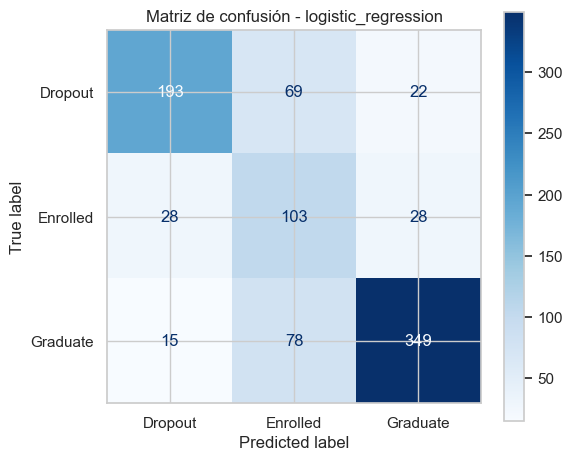

In [ ]:
# Matriz de confusión
cm = confusion_matrix(artifacts.y_test, y_pred, labels=["Dropout", "Enrolled", "Graduate"])
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Dropout", "Enrolled", "Graduate"]).plot(ax=ax, cmap="Blues")
ax.set_title(f"Matriz de confusión - {best_model_name}")
plt.tight_layout()
plt.show()



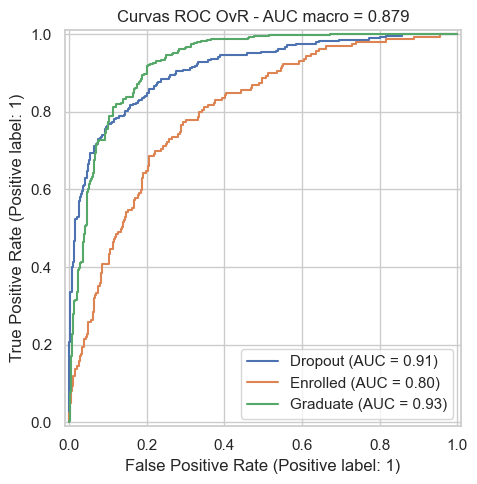

In [10]:
# Curvas ROC (One-vs-Rest)
from sklearn.preprocessing import label_binarize

classes = ["Dropout", "Enrolled", "Graduate"]
y_test_binarized = label_binarize(artifacts.y_test, classes=classes)

fig, ax = plt.subplots(figsize=(7, 5))
for idx, class_name in enumerate(classes):
    RocCurveDisplay.from_predictions(
        y_test_binarized[:, idx],
        y_proba[:, idx],
        name=class_name,
        ax=ax,
    )

roc_auc_macro = roc_auc_score(y_test_binarized, y_proba, average="macro")
ax.set_title(f"Curvas ROC OvR - AUC macro = {roc_auc_macro:.3f}")
plt.tight_layout()
plt.show()



**Hallazgos clave (test 20 % / 885 registros):**
- `logistic_regression` mantiene el mejor equilibrio global (`f1_macro ≈ 0.70`, `accuracy ≈ 0.73`) y tiempos de entrenamiento reducidos ⇒ se selecciona como modelo campeón.
- La clase `Dropout` alcanza `precision ≈ 0.82` y `recall ≈ 0.68`; conviene seguir trabajando en sensibilidad (oversampling, ajuste de umbral).
- La clase `Enrolled` es la más desafiante (`precision ≈ 0.41`, `recall ≈ 0.65`); se monitoreará de forma prioritaria en producción.
- El AUC macro calculado sobre el conjunto de prueba es ≈ 0.88, confirmando capacidad discriminativa adecuada para un primer despliegue controlado.


In [11]:
# Persistencia del modelo y metadatos de entrenamiento
MODELS_DIR = PROJECT_ROOT / "mlops_pipeline" / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

model_artifact_path = MODELS_DIR / f"best_model_{best_model_name}.joblib"
metadata_path = MODELS_DIR / "model_metadata.json"

joblib.dump(best_estimator, model_artifact_path)

metadata = {
    "model_name": best_model_name,
    "feature_count": len(artifacts.feature_names),
    "metrics_test": {
        "accuracy": float((artifacts.y_test == y_pred).mean()),
        "roc_auc_macro": float(roc_auc_macro),
    },
    "cv_metrics": cv_summary.set_index("modelo").loc[best_model_name].to_dict(),
    "feature_pipeline_path": str((PROJECT_ROOT / "mlops_pipeline" / "outputs" / "feature_pipeline.joblib").resolve()),
}

with metadata_path.open("w", encoding="utf-8") as fp:
    json.dump(metadata, fp, indent=2, ensure_ascii=False)

model_artifact_path


WindowsPath('c:/Users/jesus/OneDrive/Documentos/Proyecto Final ML/Proyecto/mlops_pipeline/models/best_model_logistic_regression.joblib')

## Próximos pasos
- Integrar el modelo y el pipeline de features en el notebook de despliegue (`model_deploy.ipynb`).
- Configurar pruebas unitarias y cobertura para SonarCloud.
- Continuar con el monitoreo de data drift utilizando `model_monitoring.ipynb`.
- Documentar resultados y decisiones en `model_evaluation.ipynb` y en el `README.md` del repositorio.
